<center><img src="redpopcorn.jpg"></center>

**Netflix**! What started in 1997 as a DVD rental service has since exploded into one of the largest entertainment and media companies.

Given the large number of movies and series available on the platform, it is a perfect opportunity to flex your exploratory data analysis skills and dive into the entertainment industry.

You work for a production company that specializes in nostalgic styles. You want to do some research on movies released in the 1990's. You'll delve into Netflix data and perform exploratory data analysis to better understand this awesome movie decade!

You have been supplied with the dataset `netflix_data.csv`, along with the following table detailing the column names and descriptions. Feel free to experiment further after submitting!

## The data
### **netflix_data.csv**
| Column | Description |
|--------|-------------|
| `show_id` | The ID of the show |
| `type` | Type of show |
| `title` | Title of the show |
| `director` | Director of the show |
| `cast` | Cast of the show |
| `country` | Country of origin |
| `date_added` | Date added to Netflix |
| `release_year` | Year of Netflix release |
| `duration` | Duration of the show in minutes |
| `description` | Description of the show |
| `genre` | Show genre |

In [102]:
# Importing pandas and matplotlib
import pandas as pd
import matplotlib.pyplot as plt

# Read in the Netflix CSV as a DataFrame
netflix_df = pd.read_csv("netflix_data.csv")

In [103]:
# Overview of data
netflix_df.head(10)
netflix_df.info

<bound method DataFrame.info of      show_id  ...             genre
0         s2  ...            Dramas
1         s3  ...     Horror Movies
2         s4  ...            Action
3         s5  ...            Dramas
4         s6  ...  International TV
...      ...  ...               ...
4807   s7779  ...          Comedies
4808   s7781  ...            Dramas
4809   s7782  ...          Children
4810   s7783  ...            Dramas
4811   s7784  ...            Dramas

[4812 rows x 11 columns]>

In [104]:
# Dataset subset for 1990s
netflix_df_90s = netflix_df[netflix_df['release_year'].between(1990, 1999)]
netflix_df_90s['release_year'].info

<bound method Series.info of 6       1997
118     1993
145     1998
167     1996
194     1993
        ... 
4672    1999
4689    1993
4718    1999
4746    1994
4756    1994
Name: release_year, Length: 184, dtype: int64>

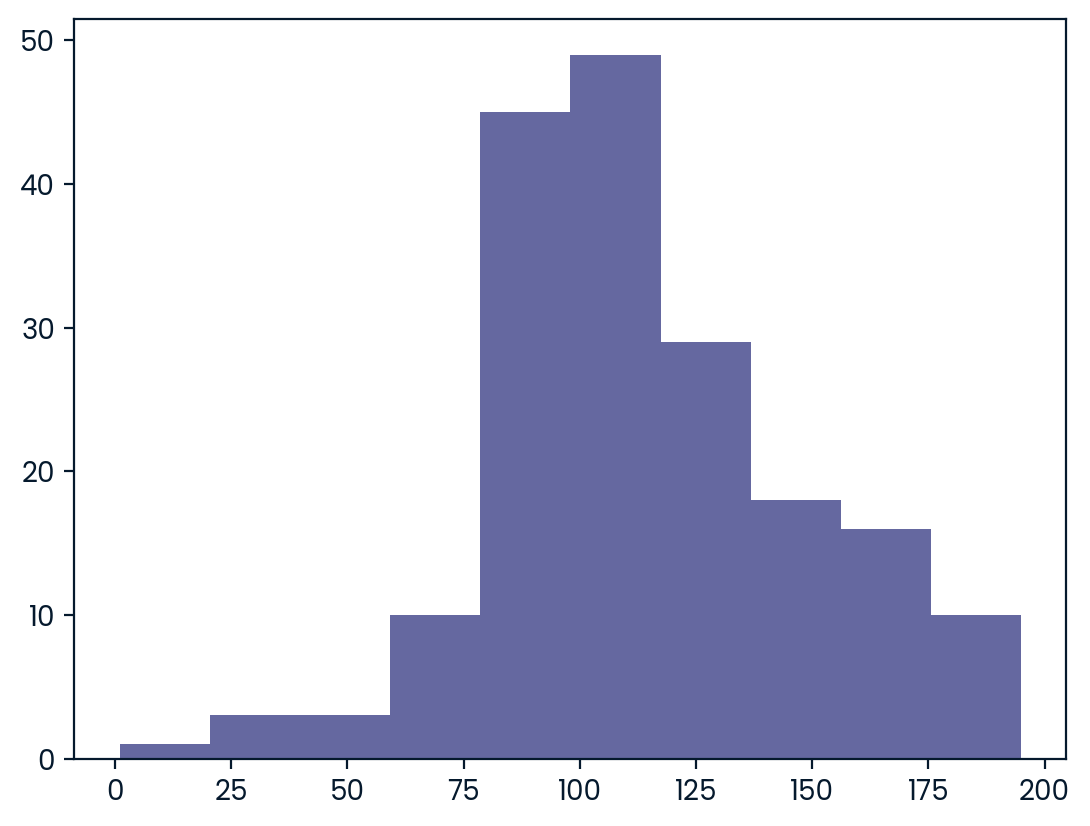

In [105]:
# Find out what the most frequent movie length was back in the 1990s
duration_values = netflix_df_90s['duration'].values
# Visual overview of distribution
plt.hist(duration_values)
plt.show()

In [106]:
from collections import Counter

def most_frequent(duration_values):
    count = Counter(duration_values)
    return count.most_common(1)[0][0] # Returns the first element with the highest number

# Saving most frequent duration as var duration
duration = most_frequent(duration_values)
print(duration)

94


_Uh-oh, spaghettios!_

There is a clear discripency between the distribution and the counter method.
Intuitavily the counter method should be correct, barring any glaring errors on my part, so a quick investigation of the graph is in order

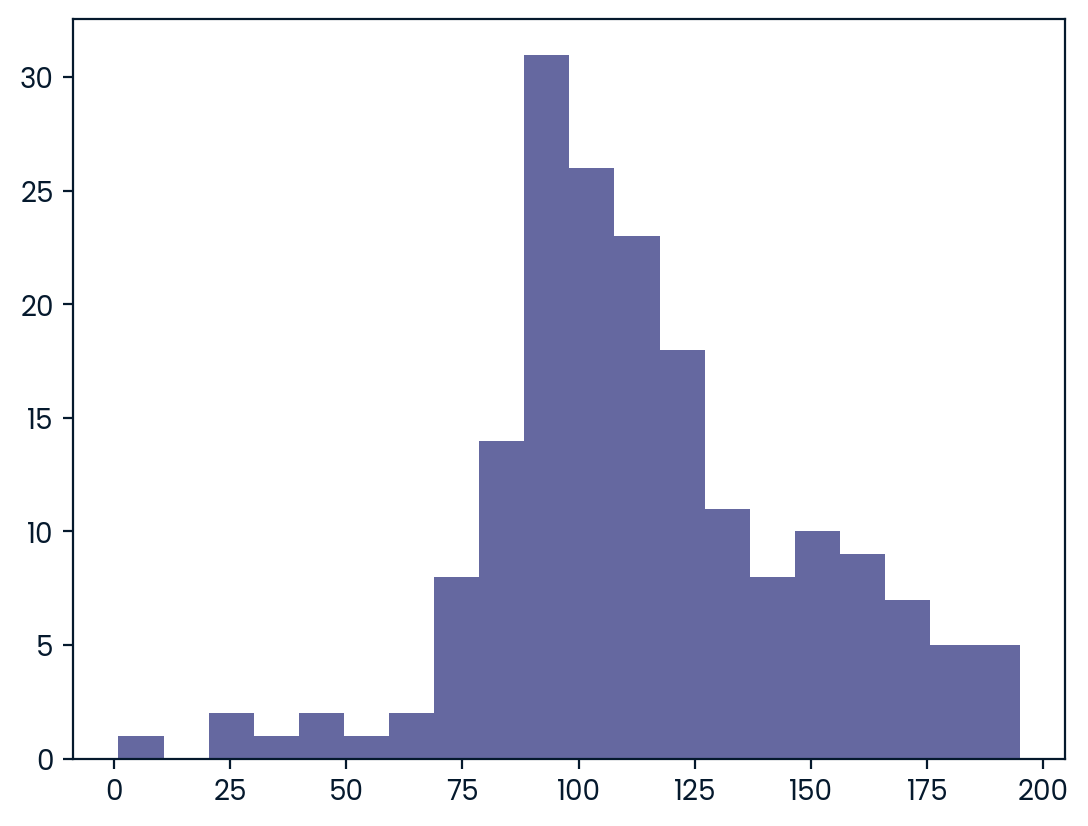

In [107]:
# As suspected the default number of bins gave an incorrect impression of data distribution
plt.hist(duration_values, bins = 20)
plt.show()

In [108]:
# Counting the frequency of short action movies; which have a runtime of < 90 minutes

short_movie_count = 0
for _, row in netflix_df_90s.iterrows(): # Iteration over each df row
    if row['type'] == 'Movie': # Check if type is movie
        if row['genre'] == 'Action': # Check if genre is action
            if row['duration'] < 90: # Check if movie duration is under 90 mins, or it'll explode
                short_movie_count += 1 # Increase integer count by 1 if all true
            
print(short_movie_count)

7


In [109]:
# Can also be written as a list comprehension where short_movie_count equals the length of the list
short_movie_count = len([1 for _, row in netflix_df_90s.iterrows() if row["type"] == "Movie" and row["genre"] == "Action" and row["duration"] < 90])
short_movie_count

7